In [1]:
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

import mediapy

import matplotlib.pyplot as plt

sim = MiniprojectSimulation(level=2, seed=42)
controller = Controller(sim)

for _ in trange(50000): # 50 000 steps pour atteindre la cible sur flat
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

sim.renderer.show_in_notebook()

# Plot une frame particuliere
# plt.imshow(controller.vision_frames[0], cmap="gray")
# plt.title("Vue de la mouche (frame 0)")
# plt.axis("off")
# plt.show()

# Vidéo des ommatidies
mediapy.show_video(controller.vision_frames, fps=sim.renderer.output_fps, title="Ommatidia readouts")



100%|██████████| 50000/50000 [05:36<00:00, 148.67it/s]


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


Ommatidia readouts This browser does not support the video tag.


In [2]:

print("mean value of left eye: ", controller.left_intensity)
print("mean value of right eye: ", controller.right_intensity)

mean value of left eye:  0.27334225
mean value of right eye:  0.25179246


Shape: (2, 16, 31)


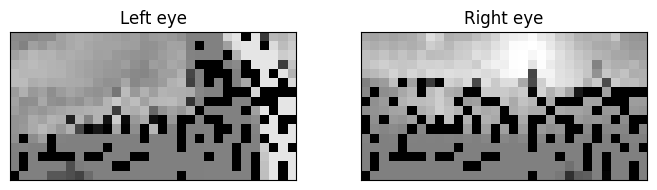

In [5]:
import numpy as np

def crop_hex_to_rect(ommatidia_readouts, ommatidia_id_map):
    """Extract a rectangular patch from the hexagonal ommatidium layout.

    Parameters
    ----------
    ommatidia_readouts : np.ndarray
        Ommatidia readings, shape ``(2, n_ommatidia, n_channels)``.
    ommatidia_id_map : np.ndarray
        2D map of ommatidium IDs from ``retina.ommatidia_id_map``.

    Returns
    -------
    np.ndarray
        Cropped rectangular image, shape ``(2, n_rows, n_cols)``.
    """
    rows = [np.unique(row) for row in ommatidia_id_map]
    max_width = max(len(row) for row in rows)
    rows = np.array([row for row in rows if len(row) == max_width])[:, 1:] - 1
    cols = [np.unique(col) for col in rows.T]
    min_height = min(len(col) for col in cols)
    cols = [col[:min_height] for col in cols]
    rows = np.array(cols).T
    return ommatidia_readouts[..., rows, :].max(-1)


imgs = crop_hex_to_rect(controller.ommatidia, sim.fly.retina.ommatidia_id_map)

fig, axs = plt.subplots(1, 2, figsize=(8, 2), tight_layout=True)
axs[0].imshow(imgs[0], cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Left eye")
axs[1].imshow(imgs[1], cmap="gray", vmin=0, vmax=1)
axs[1].set_title("Right eye")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

print("Shape:", imgs.shape)